In [1]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18


# GB regression on mono hot spot sequence 
Minimal, readable pipeline split into cells.

## 1) Imports & config

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from scipy.interpolate import PchipInterpolator
    _HAVE_PCHIP = True
except Exception:
    _HAVE_PCHIP = False

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("span", 5, 23)                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=123
)
# hgb.fit(Xtr, ytr)  # <-- comment this until Xtr, ytr exist



## 2) Utilities: one‑hot featurizer


onehot_positional	Converts each DNA sequence into a one-hot encoded numeric array (mononucleotide level)	DataFrame of 0s and 1s
Model trains on:	The frequency/pattern of each nucleotide (A/C/G/T) at each specific positio.Global features (cheap, effective):
GC fraction
length
longest poly-A and poly-T run (captures homopolymers)
k-mer features (richer sequence context):
Frequencies of observed k-mers for chosen k (e.g., 2 or 3)
Normalized by the number of windows (len(seq) - k + 1

In [3]:
import numpy as np
import pandas as pd

SEQ_COL = "sequence"


def build_X(
    df: pd.DataFrame,
    window=("span", 5, 23),
    kmer_ks=None,
    collapse_rc=True,
    add_global=False,
) -> pd.DataFrame:
    NUCS = "ACGT"

    seqs = (
        df[SEQ_COL]
        .astype(str)
        .str.upper()
        .str.replace("U", "T", regex=False)
        .map(lambda s: "".join(ch for ch in s if ch in NUCS))
    )

    mode, start, end = window
    if mode != "span":
        raise ValueError(f"Only ('span', start, end) supported, got {window}")

    cols = [f"pos{p}_{n}" for p in range(start, end + 1) for n in NUCS]
    Xpos = np.zeros((len(seqs), len(cols)), dtype=float)

    for i, s in enumerate(seqs):
        s = s.ljust(end + 1, "N")
        for p in range(start, end + 1):
            b = s[p]
            if b in NUCS:
                Xpos[i, (p - start) * 4 + NUCS.index(b)] = 1.0

    return pd.DataFrame(Xpos, columns=cols, index=df.index)

    

2) Split → train-only filtering + imputation

chosen model to rf so the rest of your notebook keeps working without edits. Even if it’s a booster, rf = est is fine.

## 4) Train, calibrate, evaluate

In [4]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# 1) Load & filter
df = pd.read_csv(INFILE)
# df = pd.read_csv("merged_output_balanced.csv")
df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Build features
def build_X(df, window=("span", 5, 23)):
    NUCS = "ACGT"

    seqs = (
        df[SEQ_COL]
        .astype(str)
        .str.upper()
        .str.replace("U", "T", regex=False)
        .map(lambda s: "".join(ch for ch in s if ch in NUCS))
    )

    # explicit inclusive span
    mode, start, end = window
    assert mode == "span"

    cols = [f"pos{p}_{n}" for p in range(start, end + 1) for n in NUCS]
    Xpos = np.zeros((len(seqs), len(cols)), dtype=float)

    for i, s in enumerate(seqs):
        s = s.ljust(end + 1, "N")  # pad if too short
        for p in range(start, end + 1):  # inclusive
            b = s[p]
            if b in NUCS:
                Xpos[i, (p - start) * 4 + NUCS.index(b)] = 1.0

    return pd.DataFrame(Xpos, columns=cols, index=df.index)

# build X and y
X = build_X(df, window=("span", 5, 23))
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

print("After build_X:")
print("n_cols =", len(X.columns))
print("pos23 =", [c for c in X.columns if "pos23_" in str(c)])
print("last 12 cols =", X.columns.tolist()[-12:])

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=bins if bins is not None else None
)

# 5) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)




# ---- Gradient Boosting instead of Random Forest ----
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

est = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=SEED,
)

# fit (with weights if your sklearn version supports it)
try:
    est.fit(Xtr, ytr, sample_weight=wtr)
except TypeError:
    est.fit(Xtr, ytr)

print("Train R² (HGB):", r2_score(ytr, est.predict(Xtr)))

# keep downstream variable name the same so the rest of your notebook works
rf = est

print("\nBefore saving:")
print("Saved feature count =", len(Xtr.columns))
print("Saved pos23 =", [c for c in Xtr.columns if "pos23_" in str(c)])

After build_X:
n_cols = 76
pos23 = ['pos23_A', 'pos23_C', 'pos23_G', 'pos23_T']
last 12 cols = ['pos21_A', 'pos21_C', 'pos21_G', 'pos21_T', 'pos22_A', 'pos22_C', 'pos22_G', 'pos22_T', 'pos23_A', 'pos23_C', 'pos23_G', 'pos23_T']
Train R² (HGB): 0.8536964117874323

Before saving:
Saved feature count = 76
Saved pos23 = ['pos23_A', 'pos23_C', 'pos23_G', 'pos23_T']


In [5]:
import joblib, json, time

# make sure these exist from the current run
assert "rf" in locals(), "rf is not defined"
assert "Xtr" in locals(), "Xtr is not defined"
assert "Xte" in locals(), "Xte is not defined"
assert "ytr" in locals(), "ytr is not defined"
assert "yte" in locals(), "yte is not defined"


print("About to save:")
print("Feature count =", len(Xtr.columns))
print("pos23 =", [c for c in Xtr.columns if "pos23_" in str(c)])

bundle = {
    "version": "seq_boost_model_with_pos23",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "seq_col": SEQ_COL,
    "seed": SEED,
    "window": ("span", 5, 23),

    # exact columns the model expects
    "feature_columns": list(Xtr.columns),

  
   

    # fitted model
    "model": rf,

    # optional saved outputs
    "y_true_te": yte,
    "y_pred_te": rf.predict(Xte),
}

joblib.dump(bundle, "seq_boost_model76.joblib")
print("Saved: seq_boost_model76.joblib")

meta = {
    "version": bundle["version"],
    "trained_at": bundle["trained_at"],
    "label_col": bundle["label_col"],
    "seq_col": bundle["seq_col"],
    "seed": bundle["seed"],
    "window": bundle["window"],
    "n_features": len(bundle["feature_columns"]),
    "pos23_columns": [c for c in bundle["feature_columns"] if "pos23_" in str(c)],
}

with open("seq_boost_model76.meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved: seq_boost_model76.meta.json")

About to save:
Feature count = 76
pos23 = ['pos23_A', 'pos23_C', 'pos23_G', 'pos23_T']
Saved: seq_boost_model76.joblib
Saved: seq_boost_model76.meta.json


## 5) Plots & saving predictions

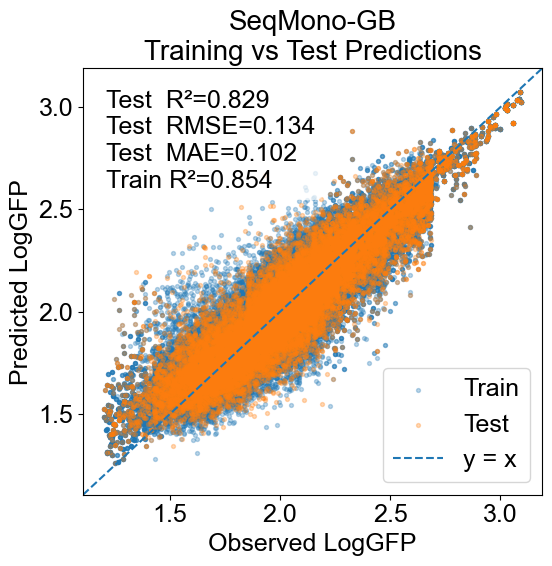

Saved figure -> rf_train_vs_test.png


In [6]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF — Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te_feature)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("HistGradientBoostingRegressor-sequence-based-mono-feature — Training vs Test Predictions.png", dpi=600, bbox_inches="tight")
    plt.savefig(
    " HistGradientBoostingRegressor-sequence-based-mono-feature-Training vs Test Predictions.pdf",
    bbox_inches="tight"
)
    plt.show()
    print(f"Saved figure -> {out_png}")

# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="SeqMono-GB\n"
                        "Training vs Test Predictions",
                       )

# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


Blue points (Train): predictions on your training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

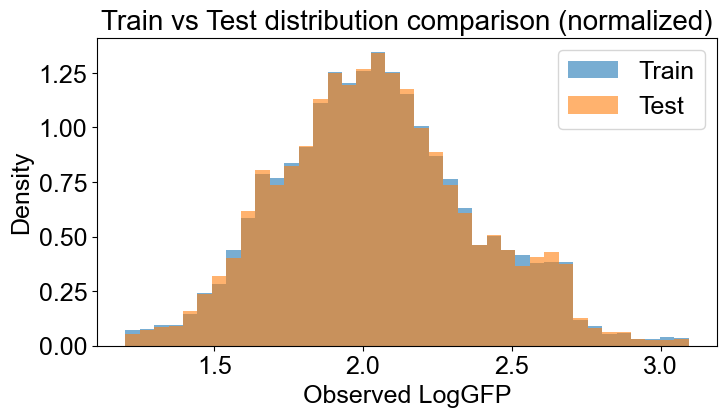

In [7]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(y.min(), y.max(), 40)  # same bins for both

plt.figure(figsize=(8, 4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP")
plt.ylabel("Density")
plt.title("Train vs Test distribution comparison (normalized)")
plt.legend()
plt.show()


see the distribution

save the model why that works all with the same rf code since I definded the booster downstrema as rf so that I could use my other code cells that I had built before

In [8]:
print("Keys in bundle:", B.keys())

NameError: name 'B' is not defined

Minimal fix to get the plot

In [ ]:
def show_and_save(fig, name):
    fig.tight_layout(); fig.savefig(f"{OUT}_{name}.png", dpi=300); plt.show(); plt.close(fig)

fig = plt.figure(figsize=(6,6))
plt.scatter(yte, yhat, s=12, alpha=0.7)
lo,hi = float(min(yte.min(),yhat.min())), float(max(yte.max(),yhat.max()))
plt.plot([lo,hi],[lo,hi],'r--',lw=1)
plt.xlabel("Observed LogGFP"); plt.ylabel("Predicted LogGFP")
plt.title("HistGradientBoostingRegressor-sequence-based-mono-feature — Training vs Test Predictions — Prediction vs Observation (calibrated)")
show_and_save(fig, "pred_vs_obs")

res = yhat - yte
fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte,res,s=10,alpha=0.6); plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP"); plt.ylabel("Residual")
plt.title("HistGradientBoostingRegressor-sequence-based-mono-feature — Training vs Test Predictions /Residuals vs Observed")
show_and_save(fig, "residuals_vs_obs")

fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--'); plt.xlabel("Residual"); plt.ylabel("Density")
plt.title("HistGradientBoostingRegressor-sequence-based-mono-feature — Training Residual distribution")
show_and_save(fig, "residual_hist")

pd.DataFrame({"y_true":yte, "y_pred_raw":yhat_raw, "y_pred":yhat}).to_csv(f"{OUT}_preds.csv", index=False)

bias = res.mean()
print("Mean residual:", bias)



NameError: name 'yhat' is not defined

<Figure size 600x600 with 0 Axes>

Check joblib

In [ ]:
import inspect
print(inspect.signature(build_X))

(df, window=('span', 5, 23))


prediction

In [ ]:
import joblib, pandas as pd, numpy as np

# load saved model
B  = joblib.load("seq_boost_model76.joblib")
rf = B["model"]
imp = B.get("imputer", None)

# --- calibrator: handle None / tuple / dict ---
cal = B.get("calibrator", None)
if cal is None:
    calib_name, calib_obj = None, None
elif isinstance(cal, tuple) and len(cal) == 2:
    calib_name, calib_obj = cal
elif isinstance(cal, dict) and {"xp","fp"} <= set(cal.keys()):
    calib_name, calib_obj = "qmap", cal
else:
    raise ValueError(f"Unrecognized calibrator format: {type(cal)}")

feature_cols = B["feature_columns"]

# load your new CSV with sequences
NEW_FILE = "All_Fasta_sequnes_constructed_features.csv"
df_new = pd.read_csv(NEW_FILE)

# rebuild features (same as training)
Xnew = build_X(
    df_new,

    
    collapse_rc=B.get("collapse_rc", True),
    add_global=True,
)

# align to training feature order
Xnew = Xnew.reindex(columns=feature_cols)
Xnew = Xnew.apply(pd.to_numeric, errors="coerce")

# impute if we saved an imputer; otherwise pass through
if imp is not None:
    Xnew_imp = pd.DataFrame(imp.transform(Xnew), columns=feature_cols, index=Xnew.index)
else:
    Xnew_imp = Xnew

# predict
y_raw = rf.predict(Xnew_imp).astype(float)

# calibrate if available
if calib_name == "iso":
    y_pred = calib_obj.predict(y_raw)
elif calib_name == "qmap":
    xp, fp = calib_obj["xp"], calib_obj["fp"]
    y_pred = np.interp(y_raw, xp, fp)
else:
    y_pred = y_raw  # no calibrator

# attach and save
out = df_new.copy()
out["LogGFP_pred"] = y_pred
out.to_csv("new_sequences_with_predictions.csv", index=False)
print("Saved: new_sequences_with_predictions.csv")

import inspect
print(inspect.signature(build_X))

TypeError: build_X() got an unexpected keyword argument 'collapse_rc'

the 6 bins, and then weakest and strongest sequnce

In [ ]:
import pandas as pd
import numpy as np

# ===== 1) Input: set this to the file your previous step wrote =====
INFILE = "predictions_sequence.tsv"   # <- produced by the loader
# If you saved TSV instead, use: INFILE = "seq_predictions.tsv"

# Auto-detect separator
df = pd.read_csv(INFILE, sep=None, engine="python")

# ===== 2) Identify columns =====
score_candidates = ["prediction"]
seq_candidates   = ["sequence", "Sequence"]

score_col = next((c for c in score_candidates if c in df.columns), None)
seq_col   = next((c for c in seq_candidates   if c in df.columns), None)

assert score_col is not None, f"No prediction column found in {INFILE}. Tried {score_candidates}"
assert seq_col   is not None, f"No sequence column found in {INFILE}. Tried {seq_candidates}"

# Helper to add core19 safely
def add_core19(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y.loc[:, "core19"] = y[seq_col].astype(str).map(lambda s: s[4:-4] if len(s) >= 9 else s)
    return y

# ===== 3) Top 3 strongest =====
top3 = df.sort_values(score_col, ascending=False).head(3).copy()
top3 = add_core19(top3)
top3.to_csv("predictions_top3_4_sequence.tsv", sep="\t", index=False)

# ===== 4) Bottom 3 weakest =====
bottom3 = df.sort_values(score_col, ascending=True).head(3).copy()
bottom3 = add_core19(bottom3)
bottom3.to_csv("predictions_bottom3_4_sequence.tsv", sep="\t", index=False)

print("Wrote:")
print(" - predictions_top3_4_sequence.tsv     (strongest 3 overall)")
print(" - predictions_bottom3_4_sequence.tsv  (weakest 3 overall)")


Wrote:
 - predictions_top3_4_sequence.tsv     (strongest 3 overall)
 - predictions_bottom3_4_sequence.tsv  (weakest 3 overall)


In [ ]:
import pandas as pd

df = pd.read_csv("new_sequences_with_predictions.csv")

def lookup(seq):
    print(df.loc[df["sequence"] == seq, ["sequence", "LogGFP_pred"]])

lookup("AAGGCCTAAGACTATACAAATAAGGCT")


Empty DataFrame
Columns: [sequence, LogGFP_pred]
Index: []


In [ ]:
import pandas as pd

# ============================
# 1. Load BIG prediction file
# ============================

big = pd.read_csv("new_sequences_with_predictions.csv")  # comma-separated by default
big = big.rename(columns={
    "sequence": "full_seq",
    "LogGFP_pred": "prediction"
})

# Strip AAAG in front & GGCT at end
big["core19"] = (
    big["full_seq"]
    .str.replace("^AAAG", "", regex=True)
    .str.replace("GGCT$", "", regex=True)
)

# Ensure max length 19 (safety)
big["core19"] = big["core19"].str.slice(0, 19)

# Keep only needed columns
big = big[["core19", "prediction"]]


# ============================
# 2. Load SMALL file
# ============================
small = pd.read_csv("new_sequnces.csv")    # comma-separated
small = small[["seq"]]                            # keep only this column

# Preserve original order
small["order"] = range(len(small))


# ============================
# 3. Merge WITHOUT sorting by prediction
# ============================
merged = small.merge(
    big,
    left_on="seq",
    right_on="core19",
    how="left"
)

# Keep only seq + prediction
result = merged[["seq", "prediction", "order"]]

# Restore the original order of the small file
result = result.sort_values("order").drop(columns="order")


# ============================
# 4. Save
# ============================
result.to_csv("seq_and_predictions.tsv", sep="\t", index=False)

print("Saved: seq_and_predictions.tsv")
print(result.head())


FileNotFoundError: [Errno 2] No such file or directory: 'new_sequnces.csv'

Beeswarm

In [ ]:
def make_shap_beeswarm_fast(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5, 3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )
    plt.title(title, loc="left")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath:
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)

    plt.show()


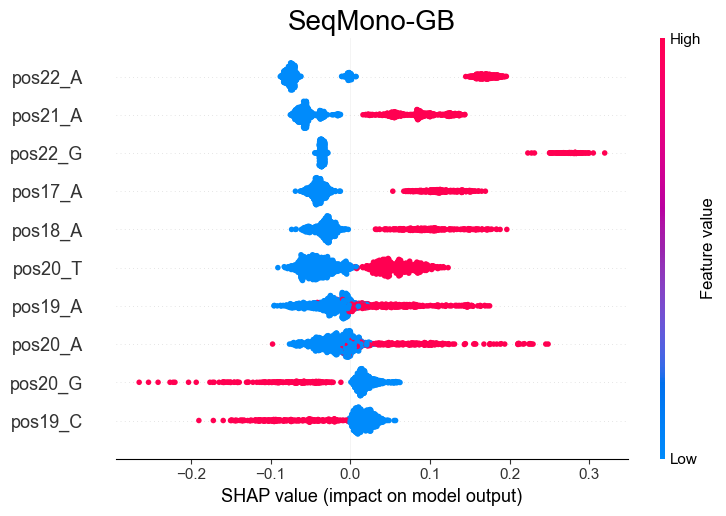

In [12]:
plt.close("all")

# --- Plot ---
shap.summary_plot(
    shap_top,
    X_top,
    feature_names=X_top.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)

fig = plt.gcf()
ax = plt.gca()

# 🔥 Remove SHAP's default strong vertical line
for line in ax.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
        line.set_alpha(0.15)        # 👈 make it very faint
        line.set_linewidth(0.5)

# OR instead completely replace it:
# line.remove()
# ax.axvline(0, color="lightgray", linewidth=0.6, alpha=0.3)

ax.set_title("SeqMono-GB")
ax.set_xlabel("SHAP value (impact on model output)")

plt.tight_layout()

fig.savefig("SeqMono_GB_Importance.pdf", bbox_inches="tight")

plt.show()
plt.close(fig)

Model prediction (LogGFP) for candidate: 2.4547877937308487


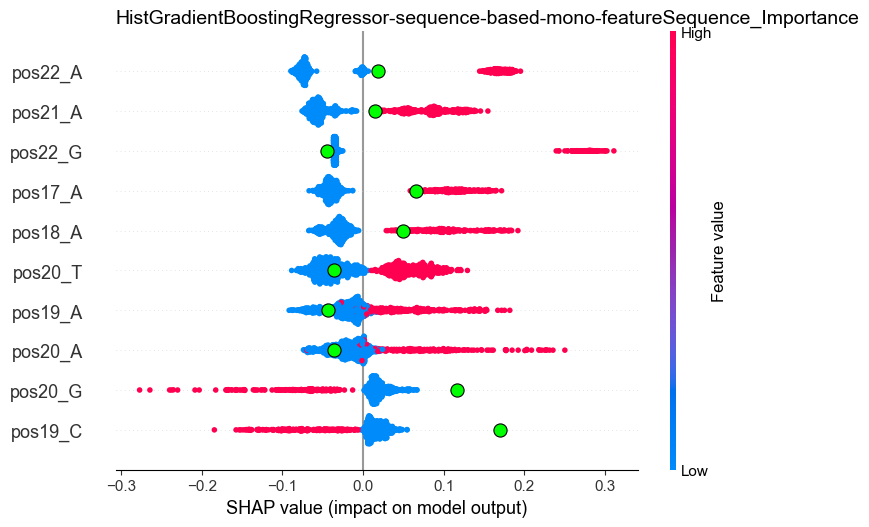

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import re
from collections import defaultdict

# ================== USER INPUT ==================
# 19-bp UP-element core of your designed sequence
my_core = "CCgcattaacgcgataaag"   # <-- change to your 19-mer

# Your trained SEQUENCE-BASED model and its test matrix
seq_model = rf      # random forest or booster trained on sequence features
Xte_seq   = Xte     # test (or train) data used to evaluate that model
# =================================================


# ---- 1. Helper: encode a 19-bp core into the sequence-model features ----
def encode_core19_for_seq_model(core19: str, feature_names) -> pd.DataFrame:
    """
    Build a 1-row DataFrame with the same columns as the sequence model expects.
    Assumes:
      - features named like pos6_A ... pos24_T
      - 2mer_XX k-mer counts
      - 3mer_XXX k-mer counts
    and that pos6..pos24 cover the 19 bp core (pos index -> core index = pos-6).
    """
    core = core19.upper()
    if len(core) != 19:
        raise ValueError(f"core19 must be length 19, got {len(core)}")

    # precompute di-/tri-nucleotide counts over the 19-mer
    di_counts  = defaultdict(int)
    tri_counts = defaultdict(int)
    for i in range(len(core) - 1):
        di = core[i:i+2]
        di_counts[di] += 1
    for i in range(len(core) - 2):
        tri = core[i:i+3]
        tri_counts[tri] += 1

    row = {}
    for f in feature_names:
        # position features: pos6_A etc.
        m = re.match(r"pos(\d+)_([ACGT])$", f)
        if m:
            pos  = int(m.group(1))     # e.g. 6..24
            base = m.group(2)
            idx  = pos - 6             # map pos6 -> core[0], pos24 -> core[18]
            if 0 <= idx < 19 and core[idx] == base:
                row[f] = 1.0
            else:
                row[f] = 0.0
            continue

        # 2-mer k-mer counts: 2mer_AC, 2mer_TG, ...
        if f.startswith("2mer_"):
            di = f[5:]
            row[f] = float(di_counts.get(di, 0))
            continue

        # 3-mer k-mer counts: 3mer_AAA, 3mer_CGT, ...
        if f.startswith("3mer_"):
            tri = f[5:]
            row[f] = float(tri_counts.get(tri, 0))
            continue

        # anything else -> default 0.0
        row[f] = 0.0

    # return as 1-row DataFrame with correct column order
    return pd.DataFrame([row], columns=feature_names)


# ---- 2. Prepare background matrix for SHAP (X_bg_seq) ----
if not isinstance(Xte_seq, pd.DataFrame):
    X_bg_seq = pd.DataFrame(Xte_seq, columns=seq_model.feature_names_in_)
else:
    X_bg_seq = Xte_seq.copy()

X_bg_seq = X_bg_seq[seq_model.feature_names_in_]
X_bg_seq = X_bg_seq.sample(min(len(X_bg_seq), 1000), random_state=42)

feature_names = seq_model.feature_names_in_

# ---- 3. Encode your 19-mer into model features ----
X_cand_seq = encode_core19_for_seq_model(my_core, feature_names)

# model prediction for this design
y_pred_cand_seq = seq_model.predict(X_cand_seq)
print("Model prediction (LogGFP) for candidate:",
      float(np.array(y_pred_cand_seq).ravel()[0]))


# ---- 4. Build SHAP explainer and compute SHAP values ----
explainer = shap.TreeExplainer(seq_model, feature_perturbation="tree_path_dependent")

shap_bg = explainer.shap_values(X_bg_seq, approximate=True)
shap_bg_vals = shap_bg[1] if isinstance(shap_bg, list) else shap_bg

shap_cand = explainer.shap_values(X_cand_seq, approximate=True)
shap_cand_vals = shap_cand[1] if isinstance(shap_cand, list) else shap_cand  # (1, n_features)


# ---- 5. Take top-k most important features and plot beeswarm ----
top_k = 10
mean_abs = np.abs(shap_bg_vals).mean(axis=0)
idx = np.argsort(mean_abs)[::-1][:top_k]

X_top_bg      = X_bg_seq.iloc[:, idx]
shap_top_bg   = shap_bg_vals[:, idx]
shap_top_cand = shap_cand_vals[:, idx]   # (1, top_k)

plt.figure(figsize=(5, 3.2))
shap.summary_plot(
    shap_top_bg,
    X_top_bg,
    feature_names=X_top_bg.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)
plt.title("HistGradientBoostingRegressor-sequence-based-mono-featureSequence_Importance", loc="left")
plt.xlabel("SHAP value (impact on model output)")

# overlay green dot for your candidate
for y_idx in range(top_k):
    x = shap_top_cand[0, y_idx]
    plt.scatter(
        x, y_idx,
        s=90,
        facecolor="lime",
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

plt.tight_layout()
plt.show()
